# 2D Trilateration for Maritime Search and Rescue

## 1. Problem Formulation
In maritime navigation and search and rescue (SAR) operations, quickly locating a distressed ship is critical. Often, ships lose their GPS navigation but continue to transmit a radio signal.

**The Case:** Three coastal stations (A, B, and C) with known coordinates intercept an SOS signal. By measuring the Time of Arrival (ToA) of the signal, the stations calculate an estimated distance to the ship. Our goal is to build a mathematical model and algorithm to calculate the $(x, y)$ coordinates of the distressed ship based on these distances.

## 2. Assumptions and Constraints
To translate the real-world problem into a correct mathematical model, we introduce the following assumptions:
* **2D Plane:** For local rescue operations, we assume the surface is a Cartesian coordinate system, ignoring the Earth's curvature.
* **Signal Propagation & ToA:** We assume the distances ($r$) are derived from the Time of Arrival (ToA) multiplied by the speed of radio waves ($c$). *Note: This is a simplified educational assumption, as real ToA requires perfectly synchronized clocks between the transmitter and receivers.*
* **Ideal Data & Unique Solution:** In the basic simulation, we assume no measurement noise. We also assume the stations are **non-collinear** (not on a single straight line). This is a strict mathematical requirement to avoid a singular matrix and guarantee a unique mathematical solution.

## 3. Mathematical Model (Analytic Geometry & Linear Algebra)

Each coastal station represents the center of a circle. The distressed ship is located at the intersection point. The equation for station $i$ with coordinates $(x_i, y_i)$ and radius $r_i$ is:

$$(x - x_i)^2 + (y - y_i)^2 = r_i^2$$

Expanding the brackets:

$$x^2 - 2x_ix + x_i^2 + y^2 - 2y_iy + y_i^2 = r_i^2$$

To eliminate the non-linear terms ($x^2$ and $y^2$) and obtain a linear system for $x$ and $y$, we use **Station A as a reference node** and subtract its equation from the equations of Station B and Station C. This yields:

$$2(x_B - x_A)x + 2(y_B - y_A)y = r_A^2 - r_B^2 - x_A^2 + x_B^2 - y_A^2 + y_B^2$$

$$2(x_C - x_A)x + 2(y_C - y_A)y = r_A^2 - r_C^2 - x_A^2 + x_C^2 - y_A^2 + y_C^2$$

This system forms the matrix equation $A \cdot X = B$, where the unknown vector is defined as $X = \begin{bmatrix} x \\ y \end{bmatrix}$. The matrix $A$ contains the coordinate differences, and vector $B$ contains the terms with radii and squared coordinates.

--- Ideal Scenario ---
Calculated Location: (60.00, 40.00)


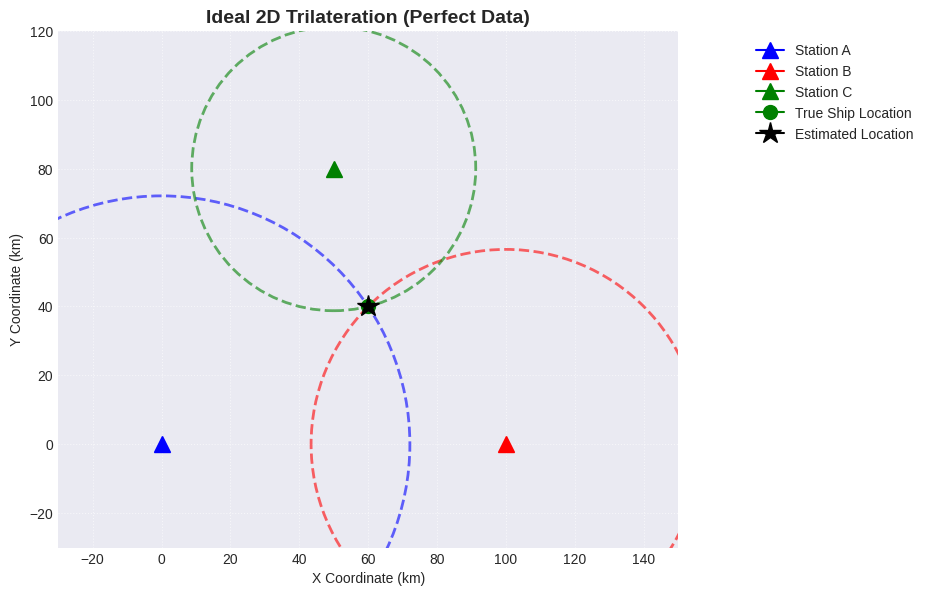

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Core Functions to avoid code repetition
def calculate_distance(p1, p2):
    """Calculates exact Euclidean distance between two points."""
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def build_linear_system(stations, radii, ref_station_key='A'):
    """Builds the A matrix and B vector for the linearized trilateration system."""
    ref_coord = stations[ref_station_key]
    ref_r = radii[ref_station_key]

    A_list, B_list = [], []

    for key in stations:
        if key == ref_station_key:
            continue
        coord = stations[key]
        r = radii[key]

        # Matrix A logic: 2(x_i - x_ref) and 2(y_i - y_ref)
        A_list.append([2 * (coord[0] - ref_coord[0]), 2 * (coord[1] - ref_coord[1])])
        # Vector B logic: r_ref^2 - r_i^2 - x_ref^2 + x_i^2 - y_ref^2 + y_i^2
        B_list.append((ref_r**2 - r**2) - (ref_coord[0]**2 - coord[0]**2) - (ref_coord[1]**2 - coord[1]**2))

    return np.array(A_list), np.array(B_list)

def plot_trilateration(stations, radii, true_loc, est_loc, title, est_color='black'):
    """Plots the stations, radii circles, true location, and estimated location."""
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = ['blue', 'red', 'green', 'purple', 'orange']

    for i, (name, coord) in enumerate(stations.items()):
        c = colors[i % len(colors)]
        ax.plot(coord[0], coord[1], marker='^', markersize=12, color=c, label=f'Station {name}')
        circle = plt.Circle(coord, radii[name], color=c, fill=False, linestyle='--', linewidth=2, alpha=0.6)
        ax.add_patch(circle)

    # Plot true location
    ax.plot(true_loc[0], true_loc[1], marker='o', markersize=10, color='green', label='True Ship Location')

    # Plot estimated location safely
    if est_loc is not None:
        ax.plot(est_loc[0], est_loc[1], marker='*', markersize=16, color=est_color, label='Estimated Location')

    ax.set_aspect('equal')
    ax.set_xlim(-30, 150)
    ax.set_ylim(-30, 120)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('X Coordinate (km)')
    ax.set_ylabel('Y Coordinate (km)')
    ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.0))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# 2. Execute Ideal Scenario
stations_ideal = {'A': (0, 0), 'B': (100, 0), 'C': (50, 80)}
true_ship_location = (60, 40)
radii_ideal = {k: calculate_distance(v, true_ship_location) for k, v in stations_ideal.items()}

print("--- Ideal Scenario ---")
A_ideal, B_ideal = build_linear_system(stations_ideal, radii_ideal, 'A')

try:
    calc_loc_ideal = np.linalg.solve(A_ideal, B_ideal)
    print(f"Calculated Location: ({calc_loc_ideal[0]:.2f}, {calc_loc_ideal[1]:.2f})")
except np.linalg.LinAlgError:
    print("Error: Singular matrix. Check if stations are collinear.")
    calc_loc_ideal = None

if calc_loc_ideal is not None:
    plot_trilateration(stations_ideal, radii_ideal, true_ship_location, calc_loc_ideal, "Ideal 2D Trilateration (Perfect Data)")

## 4. Real-World Application: Overdetermined System & Data Noise

In reality, radio signals suffer from simulated measurement errors. We use a **synthetic noise model** (`np.random.uniform`) to represent this. We also add a 4th station (Station D) intercepting the signal.

**The Math Logic:** Using Station A as a reference node and subtracting its equation from the remaining three (B, C, and D) yields exactly **3 linear equations for 2 unknowns ($x$ and $y$)**. This makes the system **overdetermined**.

Because the noisy circles will not perfectly intersect at a single point, an exact solution rarely exists. Instead, we use the **Least Squares approximation** (`np.linalg.lstsq`). Mathematically, this method calculates the $(x, y)$ coordinates that **minimize the sum of the squared residual errors** across all equations, rather than finding a perfect geometric intersection.

--- Noisy Scenario (Synthetic Noise) ---
Matrix Rank: 2 (Needs to be 2 for a unique 2D solution)
True Ship Location: (60, 40)
Estimated Location (Least Squares): (58.66, 40.26)
Sum of Squared Residuals: 6176.46


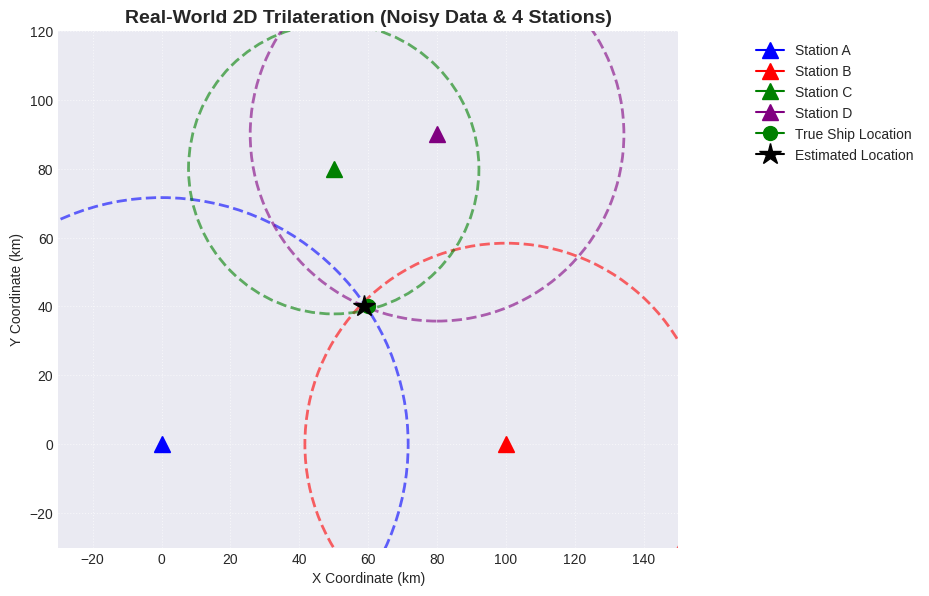

In [55]:
# 3. Setup Noisy Scenario (Overdetermined)
np.random.seed(42) # For reproducibility
error_margin = 2.0 # synthetic noise up to 2km

stations_noisy = stations_ideal.copy()
stations_noisy['D'] = (80, 90)

# Apply synthetic noise to derived distances
radii_noisy = {}
for k, v in stations_noisy.items():
    exact_r = calculate_distance(v, true_ship_location)
    radii_noisy[k] = exact_r + np.random.uniform(-error_margin, error_margin)

print("--- Noisy Scenario (Synthetic Noise) ---")
A_noisy, B_noisy = build_linear_system(stations_noisy, radii_noisy, 'A')

# lstsq returns: solution, residuals, rank, singular values
est_loc_noisy, residuals, rank, s = np.linalg.lstsq(A_noisy, B_noisy, rcond=None)

print(f"Matrix Rank: {rank} (Needs to be 2 for a unique 2D solution)")
print(f"True Ship Location: {true_ship_location}")
print(f"Estimated Location (Least Squares): ({est_loc_noisy[0]:.2f}, {est_loc_noisy[1]:.2f})")
if len(residuals) > 0:
    print(f"Sum of Squared Residuals: {residuals[0]:.2f}")

plot_trilateration(stations_noisy, radii_noisy, true_ship_location, est_loc_noisy,
                   "Real-World 2D Trilateration (Noisy Data & 4 Stations)", est_color='black')

### Interpretation of the Visualizations
* **Ideal Case:** The green dot (True Location) and the star (Calculated Location) overlap perfectly. The three circles intersect exactly at one point.
* **Noisy Case:** The circles do not share a single intersection point. The Least Squares algorithm places the estimated location (black star) at the mathematical coordinate that minimizes the overall discrepancy (residuals) from all 4 stations. This explains why the estimated point slightly deviates from the true location.

## 5. Limitations and Future Improvements

### Limitations
* **2D Approximation:** Ignores the Earth's curvature, limiting applicability to small, localized areas.
* **Idealized ToA:** Assumes perfect clock synchronization between transmitter and receivers (no timing bias).
* **Environmental Factors:** Ignores multipath effects, signal reflection, and atmospheric conditions that distort radio waves.

### Future Improvements
* **3D Model:** Incorporate altitude/elevation for aviation or submarine SAR.
* **TDoA (Time Difference of Arrival):** Use TDoA instead of ToA to eliminate the need for a perfectly synchronized clock on the distressed ship.
* **Weighted Least Squares:** Assign higher confidence (weights) to stations with better signal quality.
* **Confidence Ellipse:** Calculate and plot the statistical area of probability around the estimated location.

## 6. Conclusion
This project successfully demonstrated the mathematical principles of 2D trilateration applied to a Search and Rescue scenario. We translated a physical navigation problem into a system of linear equations. Under ideal conditions with non-collinear stations, the exact location is found using matrix inversion. By introducing simulated measurement error and a 4th station, we modeled an **overdetermined system**, proving that the **Least Squares method** is required to find the optimal location by minimizing the sum of squared residuals.

This workflow illustrates a fundamental mathematical principle behind modern positioning systems.

## 7. References
* **Trilateration Mathematical Concepts:** *Wikipedia, Trilateration*. (Theory applied in Sections 1-3).
* **Linear Algebra Solvers:** * NumPy Documentation, `numpy.linalg.solve` (Used in Section 3 for ideal data).
    * NumPy Documentation, `numpy.linalg.lstsq` (Used in Section 4 for overdetermined systems and residual analysis).
* **Data Visualization:** Matplotlib Documentation, *Pyplot tutorial*.